# THE Window Trubine AI-Driven Chatbot PROJECT

## What is the Window Trubine AI -DrivenChatbot Project?        
Enbridge is a leading energy infrastructure company headquartered in Canada. It primarily operates in the transportation and distribution of energy resources, especially oil, natural gas, and renewable energy.

he Project was built for EN Bridge, a company operating in the renewable energy sector. The project focused on creating an AI-powered assistant specifically designed for wind turbine field engineers — the people physically responsible for maintaining and repairing wind turbines in the field.



## Understanding Wind Turbines and Their Challenges

Wind turbines are large and complex machines that operate continuously in harsh environmental conditions like strong winds, temperature changes, and mechanical stress. Because of this, they can experience various technical issues such as high wind pressure, torque problems, abnormal vibrations, structural stress, and component damage. These issues can affect parts like blades, gearboxes, generators, and towers, and if not addressed quickly, they can lead to serious mechanical failures and turbine downtime.

## The Traditional Troubleshooting Process — Why It Was Broken

when a wind turbine issue occurred, field engineers had to manually search through large technical documents such as manuals, maintenance reports, diagrams, and PDFs to find the cause and solution. This process was time-consuming and difficult, often taking hours because engineers needed to know exactly where to look in hundreds of pages of documentation. During turbine failures, this delay caused longer downtime and financial loss. The main challenge was the gap between complex documentation and the engineer’s need for quick, practical answers in the field.

## The Vision — What Was Built to Solve It

The team built an intelligent conversational AI system where an engineer could simply type a question in plain, natural language — like "The turbine tower is swaying excessively in 15 m/s winds, what should I check?" — and receive an immediate, precise, step-by-step answer sourced directly from the company's own technical documents, manuals, and maintenance history. No more manual searching. No more guessing. Just accurate, document-backed guidance in seconds.

#  THE RAG PIPELINE 

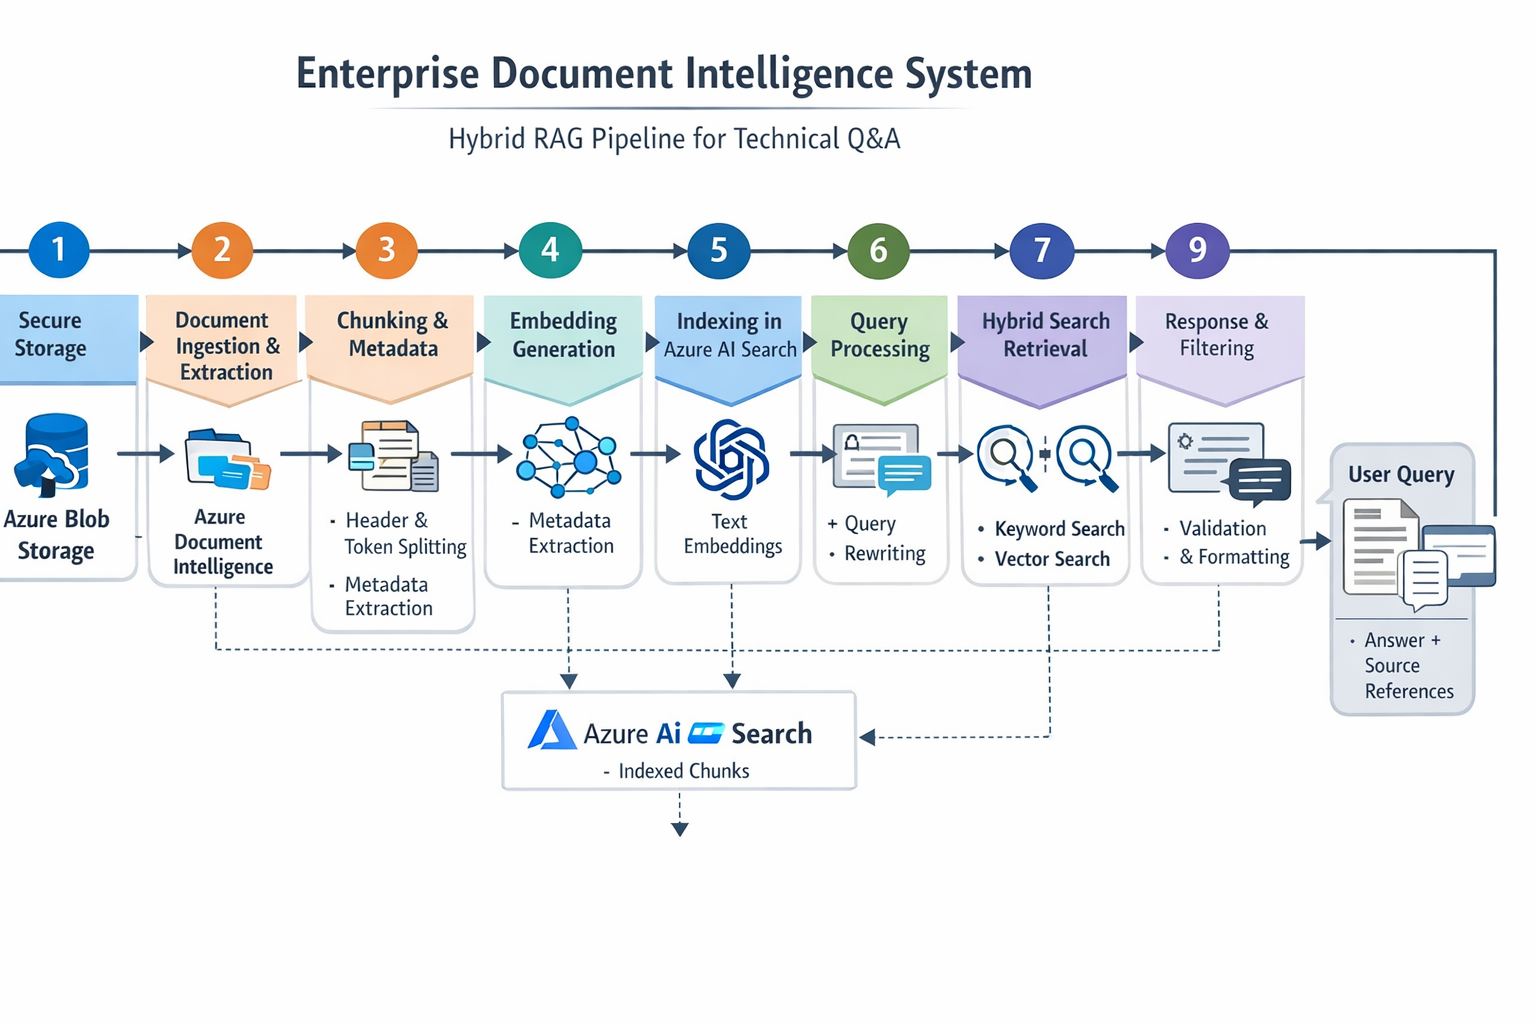

## Step 1 — Secure Document Storage and Ingestion
All company documents (manuals, reports, diagrams, and safety guidelines) are stored in Microsoft Azure Blob Storage, which provides centralized, scalable, and secure storage. During the ingestion stage, the pipeline retrieves these files and prepares them for further processing in the AI pipeline.

## Step 2 — Text and Image Extraction with Structured Output

Azure Document Intelligence extracts content from PDFs, scanned files, and images. It identifies document structure (headings, paragraphs, tables, lists) and uses OCR(Optical Character Recognition )  to extract text from scanned documents and diagrams.

The output is converted into structured Markdown instead of plain text, preserving headers and document hierarchy for better chunking, embedding generation, and indexing in the RAG pipeline.

For images, the service detects figures and provides metadata (figure ID, page number, bounding box, caption). Using PyMuPDF, images are extracted from PDFs and saved separately (e.g., figure_1.png), then referenced in the Markdown file.


This was one of the more interesting engineering challenges. During ingestion, Azure Document Intelligence identifies images on each page and returns their bounding box coordinates. We extract those images and store them in Azure Blob Storage with the path pattern /images/{doc_id}/{page_number}/{image_index}. When we index each text chunk, we attach an image_refs field to its metadata — a list of image IDs corresponding to images on the same page as that chunk. When a user asks a question and we retrieve the top-K chunks, each chunk comes back with its image_refs metadata. FastAPI then calls Azure Blob Storage to generate time-limited SAS URLs for each referenced image — valid for 30 minutes so they're not cached indefinitely. The final JSON response includes the text answer AND an array of image objects with URL, page number, and a caption extracted from the document. The frontend renders these side by side: the step-by-step instructions on the left, the corresponding diagram on the right.


## Step 3  Chunking Strategy (Technical Explanation based on the Code Flow)

First, the Markdown content is split based on document headers using a header-based splitter. This preserves the logical structure of the document, so related sections such as procedures, maintenance steps, or alarms stay together.

Next, the chunks are optimized using token-based splitting. Smaller sections are merged until they reach the configured chunk size, while larger sections are split further using a recursive text splitter.

The system also applies overlapping chunking, where a small portion of the previous chunk is repeated in the next chunk. This prevents important information from being lost when content spans across chunk boundaries.

After chunk creation, Azure OpenAI Service is used to extract structured metadata from each chunk, such as procedure name, procedure codes, procedural steps, alarm codes, related figures or tables, and a short summary.

Finally, the chunk content and metadata are stored in structured JSON format.

## Step 4: Embedding Generation

In this step, each document chunk is converted into a vector embedding using text-embedding-ada-002. The embedding is a 1536-dimensional vector that captures the semantic meaning of the text.

This allows the system to perform semantic search, where similar meanings can be matched even if the words are different. All document chunks are converted into embeddings and stored.

## Step 5 — Azure AI Search Index (Technical Summary)

In the indexing stage, each processed document chunk is stored in Azure AI Search along with its metadata and embedding vector.

For every chunk, we store the text content, metadata (such as document name, page number, section, and component type), and the embedding vector generated from the text. The text fields are indexed for keyword search, while the embedding vectors are stored in a vector field for semantic similarity search.

## Step 6: Query Processing Pipeline (Technical)

When an engineer submits a query, it is first cleaned and normalized using regex to remove special characters, extra spaces, and formatting noise so the query becomes standardized.

The system checks whether the query is a new question or a follow-up. If it is a follow-up, previous conversation history is retrieved from Azure Cosmos DB (for persistent history).

The current query and previous context are combined to rewrite the query into a clear standalone question. This ensures references like “it” or “that issue” are properly understood.

The rewritten query is then sent to Azure AI Search for retrieval using both keyword and semantic search.

## Step 7: Hybrid Search Execution (Technical)

In this stage, the system performs hybrid retrieval using Azure AI Search to find the most relevant document chunks.

First, keyword search is performed using BM25, which retrieves chunks containing exact matches of the query terms. This is useful for technical queries involving error codes, component IDs, or specific terminology.

At the same time, the query is converted into an embedding, and vector search is performed using KNN (K-Nearest Neighbors). The system finds the top K closest document vectors to the query vector based on cosine similarity, enabling retrieval of semantically similar chunks even when the wording differs.

Finally, the results from both searches are combined using RRF (Reciprocal Rank Fusion), which merges and re-ranks the results to produce the Top-K most relevant chunks, which are then passed to the LLM for answer generation.

## Step 8: LLM Answer Generation (Technical)

The Top-K retrieved chunks and their metadata are sent to Azure OpenAI Service to generate the final answer.

A structured prompt is created in the backend that includes the user query, retrieved chunks, and metadata such as document name and page number. A system prompt guides the model to answer only from the provided context, give clear step-by-step explanations, and cite sources.

This ensures grounded responses, reducing hallucinations and producing reliable answers with references to the relevant documents.

## Step 9: Response Structuring and Filtering

After the LLM generates an answer, the FastAPI backend performs post-processing checks before returning the response.

First, a confidence check evaluates the relevance of retrieved chunks from Azure AI Search. If similarity scores are low, the system flags the response.
Finally, the backend formats the result into a structured JSON response containing the generated answer, source document references, confidence metadata, and the session ID for conversation tracking.

# SECURITY ARCHITECTURE

## Authentication & Authorization

The system uses OAuth 2.0 with single-tenant Azure Active Directory. RBAC controls access: field engineers can query, administrators have full access, and supervisors have read-only access.

## Single-Tenant Authentication

Using single-tenant Azure Active Directory, authentication is handled by Azure AD via OAuth 2.0, and no separate database is needed. Tokens are validated by the application, and RBAC controls user access. A database is only required if you want to store additional user-specific data.

## Why Single-Tenant

Single-tenant Azure AD is used because it restricts access to your organization, simplifies user and role management, and ensures consistent security and compliance. It’s ideal for internal tools where all users belong to the same company

## Data Security 

Documents are stored privately in Azure Blob Storage and accessed via SAS tokens for authorized users only. All user inputs are sanitized to prevent prompt injection attacks on the LLM.

## Stateless Architecture

The API is stateless, meaning each request is independent and contains all necessary information.  and the server does not keep session data in memory. This design enables horizontal scaling, as any server instance can handle any request, making it easy to handle high-demand periods by adding more servers.


Improved Maintenance Accuracy

By retrieving information directly from official technical documents, the system ensures engineers make accurate, informed maintenance decisions, reducing reliance on memory or generic internet searches.

## Knowledge Democratization

The system captures institutional knowledge from historical maintenance reports and guides, making it accessible to all engineers, so expertise doesn’t leave when senior staff retire.

Scalability and Future-Proofing

Built on Azure cloud infrastructure, the system scales automatically as turbines, documents, and users increase. New manuals and reports can be continuously ingested, keeping the knowledge base up to date without redesign.

## Scalability and Future-Proofing 

Built on Azure cloud infrastructure, the system scales automatically as turbines, documents, and users increase. New manuals and reports can be continuously ingested, keeping the knowledge base up to date without redesign.

# Complete Interview Questions & Answers — Landa Wind Turbine AI Project


## Q1. Can you walk me through the Landa Project and what problem it was solving?
Answer:
The Landa Project was an AI-powered assistant built for EN Bridge, a wind energy company. The core problem was that wind turbine field engineers were spending enormous amounts of time manually searching through hundreds of pages of technical manuals, maintenance reports, PDFs, and engineering diagrams every time they encountered a turbine issue like vibration, torque problems, pole misalignment, or structural damage.
This manual search process was slow, error-prone, and extremely costly during critical failures because every minute of turbine downtime means lost energy production and revenue. To solve this, we built a Hybrid RAG (Retrieval-Augmented Generation) system where engineers could simply ask a question in plain English and immediately receive a precise, step-by-step, document-backed answer. The system significantly reduced response time, improved maintenance accuracy, and reduced overall turbine downtime.

## Q2. Why did you choose RAG architecture instead of just fine-tuning an LLM?
Answer:

Fine-tuning LLMs has major limitations for our domain. First, knowledge in a fine-tuned model is fixed—any time new manuals or procedures are added, the model must be retrained, which is time-consuming and expensive. Second, fine-tuned models can hallucinate and cannot cite exact sources, which is risky in safety-critical environments like wind turbine maintenance.

RAG solves these problems by retrieving relevant documents at query time. New documents are immediately available without retraining. It’s cost-efficient, as we only pay for embeddings and inference, not GPU training. Importantly, it provides full transparency and auditability, with citations to specific documents, pages, and sections, ensuring engineers can verify every recommendation.

## Q3: What was your specific role and contribution in this project?

Answer:
I was responsible for designing and implementing the end-to-end RAG pipeline. My contributions included:

Designing the document ingestion and chunking strategy.

Setting up and configuring Azure AI Search with both keyword and vector indexes.

Integrating text-embedding-ada-002 for embedding generation.

Building the hybrid search logic combining keyword and vector retrieval.

Developing the FastAPI backend to orchestrate the entire flow.

Implementing conversation context management using Redis and Cosmos DB.

Designing the prompt engineering strategy to minimize hallucinations.

Setting up the security layer with JWT authentication and role-based access control.

This allowed the system to provide accurate, traceable, and secure responses to engineers in real time.

## Q5 Question: Why did you choose 400–800 tokens as your chunk size? What happens if chunks are too small or too large?


Chunk size is a critical hyperparameter in a RAG system because it directly affects retrieval and answer quality.

Too small (50–100 tokens): Chunks lack sufficient context. For example, a sentence fragment about a "bearing failure" without surrounding details becomes meaningless to the LLM, and semantic retrieval precision drops.

Too large (2000+ tokens): Chunks may cover multiple topics, causing imprecise retrieval, wasted LLM tokens, higher cost, and diluted context quality.

We chose 400–800 tokens because technical manuals typically contain well-structured sections of this length that cover a single topic completely. This ensures each chunk is semantically coherent and focused.

We also include 50–100 token overlap between consecutive chunks so that information at chunk boundaries is captured in at least one adjacent chunk, preserving context for accurate answers.

##  What is cosine similarity and why did you use it for vector search?

cosine similarity measures how similar two vectors are by calculating the angle between them in a multi-dimensional space. The value ranges from -1 to 1, where 1 means highly similar, 0 means no relation, and -1 means opposite meaning.

It is used in vector search because text embeddings represent meaning through the direction of vectors rather than their magnitude. Cosine similarity focuses on this direction, allowing it to accurately find semantically similar texts even if their lengths differ.

For example, a short two-sentence troubleshooting note and a detailed three-page analysis of the same turbine issue would both produce embeddings pointing in similar directions in the 1536-dimensional space, and cosine similarity would correctly identify them as related.

## What embedding model did you use and why? What does 1536-dimensional mean?

We used OpenAI text-embedding-ada-002 as the embedding model. It was chosen because it generates high-quality semantic embeddings, works well with technical or domain-specific text, integrates smoothly with Azure OpenAI Service, and is cost-efficient for production systems.

The 1536-dimensional part means that every text (document chunk or query) is converted into a vector of 1,536 numbers. Each number represents a small aspect of the text’s meaning. Together, these numbers position the text as a point in a high-dimensional space, where texts with similar meanings are located close to each other.

## Why did you choose Azure AI Search over other vector databases like Pinecone, Weaviate, or ChromaDB?

We chose Azure AI Search because our system was already running on Microsoft Azure services like Azure OpenAI Service and Azure Blob Storage. It provided easy integration, built-in security, and unified billing, making it more convenient than external vector databases like Pinecone or Weaviate.

Finally, Azure AI Search scales automatically and offers semantic re-ranking capabilities out of the box, which further improved our retrieval quality beyond basic vector similarity.

## What is the top-K parameter and how did you decide what value to use?

Top-K refers to the number of document chunks retrieved from the search index and sent to the LLM as context. For example, K = 5 means the system returns the 5 most relevant chunks.

Choosing the right value involves a trade-off:

A higher K provides more context and increases the chance of including the correct information.

However, it also increases token usage, cost, and latency, and too many chunks may introduce irrelevant information (noise).

In our system, K was configurable. Typically 3–5 worked well for simple queries, while 8–10 was better for complex questions. We determined the optimal default value through testing and evaluation of query results.

## Why did you choose FastAPI over Flask or Django for this project?

We chose FastAPI because 

FastAPI uses async/await, which allows it to handle many concurrent requests efficiently—important for an AI system that makes multiple calls to services like Azure AI Search and Azure OpenAI Service.

It also uses Pydantic for automatic request validation and generates interactive API documentation with Swagger UI.

Compared to Flask (limited async support) and Django (heavier full-stack framework), FastAPI was better suited for a high-performance API-based AI service.

## How did you handle conversation context and follow-up questions in FastAPI?

LLMs are stateless, so we stored conversation history externally to handle follow-up questions. We used Azure Cosmos DB to store and retrieve conversation sessions.

When a request arrives in FastAPI, the system retrieves the previous conversation turns using the session ID from Cosmos DB and appends them to the current query before sending it to the search system and LLM.

For follow-up questions, we used simple heuristics (such as pronouns like “it” or continuation phrases). When detected, the system includes the relevant previous messages from Cosmos DB so the model can understand the context correctly.   

## How did you structure the LLM prompt and why does prompt engineering matter here?

Prompt engineering is crucial in a RAG system because the prompt guides how the LLM interprets context and generates answers. A well-designed prompt helps reduce hallucinations and ensures accurate responses.

Our prompt had three main parts:

System instructions – The model was instructed to act as a wind turbine maintenance expert, answer only using the provided context, cite document sources, give structured troubleshooting steps, and say when information is insufficient.

Context section – Retrieved document chunks were included with source details like document name, page number, and section.

User query – The cleaned and context-enriched user question.

We also added few-shot examples to demonstrate the expected answer format. This improved consistency, accuracy, and traceability of responses for engineers

## How did you implement security in this system? Answer?

Authentication: API endpoints in FastAPI were protected using JWT tokens. We also supported OAuth 2.0 integration with Azure Active Directory for enterprise single sign-on.

Authorization: Implemented Role-Based Access Control (RBAC) to restrict actions for roles such as engineers, document admins, and system admins.

Data Security: Documents were stored privately in Azure Blob Storage, with controlled access using temporary SAS tokens.

Input Protection: User queries were sanitized to prevent prompt injection attacks.

Secrets & Encryption: Sensitive keys were stored in Azure Key Vault, and all communication used HTTPS with TLS encryption.

This ensured secure authentication, controlled access, and protection of both data and LLM interactions. 🔐

## How would you scale this system if the number of users grows from 50 to 50,000?

To scale from 50 to 50,000 users on Azure, I’d deploy the compute layer on AKS or Azure Container Apps with autoscaling, and use Azure API Management for rate limiting and traffic routing. Since token throughput is a key bottleneck, I’d use provisioned throughput units and introduce semantic caching with Redis to reduce repeated calls. For the RAG pipeline, I’d scale Azure AI Search with replicas and partitions, and decouple ingestion using Service Bus and Azure Functions. Finally, I’d implement observability with Application Insights and enforce cost governance using per-user quotas and budget monitoring

## How did you measure the success of this system?

We measured the system’s success using technical metrics and business impact.

Technical evaluation:
We created an offline dataset of about 50 representative questions with known answers from the documents. We evaluated:

Retrieval recall – whether the correct document chunks appeared in the top-K results

Answer faithfulness – whether the LLM’s response was grounded in the retrieved context

Answer relevance – whether the answer actually addressed the user’s question

These metrics were calculated using RAGAS. We also monitored production metrics such as average query latency, percentage of high-confidence answers, and user feedback ratings.

Business impact:
We tracked time-to-resolution for turbine maintenance incidents, reduction in turbine downtime, and fewer escalations from junior engineers to senior engineers.

Together, these metrics showed both the technical effectiveness and real operational value of the system.

## If you were to rebuild this project from scratch today, what would you do differently?

If rebuilding the system today, several improvements could be made based on newer tools and lessons learned.

First, we would use a more advanced embedding model like text-embedding-3-large instead of OpenAI text-embedding-ada-002, since it offers better semantic accuracy and multilingual performance.

Second, we would implement semantic chunking instead of fixed token-size chunking so that document sections are split based on meaning and structure, improving retrieval quality.

Third, we would build an evaluation framework earlier using tools like RAGAS, enabling data-driven decisions during development.

We would also consider an agentic approach for complex queries, where the system breaks a question into smaller sub-questions, retrieves information for each, and then combines the results.

Finally, we would create a stronger document processing pipeline that captures document structure (sections, headings, and references) as metadata, enabling more precise and structured retrieval.

## Why are you filtering search results using the reranker score instead of using all retrieved documents?

After retrieving search results, the system calculates the average search score of all returned documents. It then applies a score-based filter using the reranker score, keeping only the document chunks whose score is higher than the average.

This ensures that only the most relevant results are selected and less relevant documents are removed before passing the context to the LLM.


##  Walk me through the exact structure of the request payload sent to your FastAPI endpoint.

The request payload includes fields like session_id, question, include_history, and top_k. We defined the schema using a Pydantic model in FastAPI for automatic validation. The session_id is typically generated by the frontend and passed with each request so the backend can retrieve conversation history from Cosmos DB.

## How did you set up the Azure AI Search index for your RAG system?

We created an index in Azure AI Search to support our RAG system. The index stores document chunks, embeddings, and metadata so the system can retrieve relevant information efficiently.

The index includes several types of fields:

1. Key Field

Id – unique identifier for each document chunk.

2. Searchable Content Fields

Procedure_Name

Procedure_Summary

Procedure_Chunk

Procedure_Steps

Alarm

These fields allow keyword and semantic search.

3. Metadata Fields
Metadata helps trace results back to the original document and provide additional context:

metadata_file_name

metadata_file_storage_path

metadata_csv_storage_path

metadata_image_storage_path

metadata_creation_date

metadata_modified_date

4. Vector Field

content_vector – stores embeddings with 1536 dimensions, generated using OpenAI text-embedding-ada-002.

## When a user asks a question, how does the system return both text steps AND relevant images?

When a user queries the system, the backend returns both the text steps and the image URLs stored in Azure Blob Storage. The frontend then renders these URLs as inline images so the user sees the diagrams alongside the instructions, rather than just the raw URL. This keeps the LLM focused on text and ensures a seamless visual experience for the user.



In [ ]:
{
  "query": "How do I inspect the gearbox for vibration issues?",
  "response": {
    "chunks": [
      {
        "chunk_text": "1. Shut down the turbine and isolate power.\n2. Remove the gearbox cover.\n3. Inspect the bearings for wear or overheating.\n4. Check the alignment of the shafts.\n5. Record any abnormal vibration readings using sensors.",
        "document_name": "Maintenance_Manual.pdf",
        "page": 124,
        "section": "Gearbox Diagnostics",
        "component_type": "Gearbox",
        "images": [
          {
            "image_url": "https://<blob-storage-path>/gearbox_diagram_124.png",
            "description": "Gearbox diagram showing bearings and gears"
          },
          {
            "image_url": "https://<blob-storage-path>/bearing_alignment.png",
            "description": "Diagram showing correct bearing alignment"
          }
        ]
      },
      {
        "chunk_text": "6. After inspection, reassemble the gearbox cover and restore power. Ensure all safety checks are performed.",
        "document_name": "Maintenance_Manual.pdf",
        "page": 125,
        "section": "Gearbox Reassembly",
        "component_type": "Gearbox",
        "images": []
      }
    ]
  },
  "metadata": {
    "retrieved_chunks_count": 2,
    "timestamp": "2026-03-15T12:30:00Z",
    "source": "Azure AI Search + Cosmos DB"
  }
}

## How did you manage environment variables and secrets in Azure?
💡 Hint: Azure Key Vault for secrets (API keys, connection strings). App Settings in Azure App Service/Container Apps reference Key Vault via managed identity. Never hardcode credentials.


## How did you scale the application to handle multiple simultaneous user queries?

To handle multiple simultaneous user queries, I used FastAPI async endpoints so requests are non-blocking. Frequently repeated queries are cached in Azure Redis to reduce load. The app is deployed in Azure Container Apps with auto-scaling based on CPU, memory, or custom KEDA triggers, so it can handle traffic spikes automatically. For search functionality, Azure AI Search handles concurrent queries efficiently on its own. This combination ensures fast, reliable, and scalable performance under load.”

## What is Azure Container Registry and how does it fit in your deployment?

ACR is a private Docker image registry on Azure. GitHub Actions builds and pushes the Docker image to ACR. Azure Container Apps pulls from ACR to deploy. Tight integration with Azure IAM.

## How did you diagnose whether the problem was in retrieval or in LLM generation?
We logged the top-K retrieved chunks for each query. If the chunks were relevant but the answer was wrong or hallucinated, the issue was with LLM generation. If the chunks were irrelevant or off-topic, the problem was in retrieval. Logging both consistently helped pinpoint the root cause.”

## What changes did you make to fix poor retrieval quality?
“We improved retrieval by:

Switching from keyword-only search to Hybrid Search.

Adding a semantic ranker to better order results.

Improving chunking with overlap and section-aware splits.

Adding domain-specific metadata for filtered search.

Cleaning queries to remove noise and ambiguity.”

## How did you fix LLM hallucinations in the system?
“Hallucinations were reduced by:

Using a strict prompt: ‘Answer ONLY from context, do not use outside knowledge.’

Increasing Top-K to provide more context.

Adding confidence scoring to flag uncertain answers.

Returning ‘I don’t have information’ when no relevant chunks were found.”

## How did you evaluate retrieval quality? What metrics or methods did you use?
“We measured retrieval quality using:

MRR (Mean Reciprocal Rank) — was the correct chunk in top-3?

NDCG for ranking quality.

Human annotation of 50–100 test queries.

Automated evaluation with LangChain / RAGAS framework.”

## What is RecursiveCharacterTextSplitter and why is it better than simple character splitting?     

RecursiveCharacterTextSplitter splits text hierarchically—paragraph → sentence → word—to preserve semantic meaning in each chunk. Unlike simple character splitting, which can cut mid-sentence, it keeps chunks contextually complete, improving retrieval quality and helping LLMs generate more accurate answers.

## HNSW
Hierarchical Navigable Small World (HNSW) is a **graph-based ANN algorithm** used for fast vector similarity search. It efficiently navigates high-dimensional spaces to find nearest neighbors. Azure AI Search uses it to quickly retrieve relevant embeddings.


## A brute force algorithm (often referred to as an exhaustive search) 

is a straightforward problem-solving technique that systematically tests every possible candidate solution until the correct one is found.

## RRF
Reciprocal Rank Fusion (RRF) combines the results of keyword and vector searches. It does this by **adding the reciprocal of each result's rank**, producing a more balanced final ranking. This improves retrieval accuracy for hybrid search systems.

## BM25
BM25, or Best Match 25, is a **probabilistic keyword ranking algorithm**. It scores documents based on query term frequency and document length. It forms the foundation of traditional text search in Azure AI Search.

## ANN search
Approximate Nearest Neighbor (ANN) search finds vectors that are **closest to a query vector in high-dimensional space**. It is much faster than exact nearest neighbor search. ANN is commonly used for embeddings-based retrieval in LLM systems.


## KNN Seach 

vector search, KNN is used to retrieve the top K most similar embeddings to a query vector using similarity metrics like cosine similarity. It is a core component of RAG systems for finding relevant context.”

## tiktoken
`tiktoken` is **OpenAI’s tokenizer library**. It counts the number of tokens in a string to ensure that prompts **fit within the model’s context window**. Proper token counting helps avoid truncation or errors when sending requests to the LLM.

## Since you chunk documents before embedding, does each chunk have its own independent embedding with no connection to the full document?

By default, each chunk is embedded independently, so the model can’t know what previous chunks said. To preserve context, I either prepend a document-level summary to each chunk, use parent-document retrieval, or include section metadata in the chunk before embedding.

## Azure AI Search returns top-K results. If you set K=10, you always get exactly 10 chunks back, right?

No — Azure AI Search doesn’t always return exactly K results. If fewer chunks meet the minimum score threshold, or if a semantic reranker caps the results, you can get fewer than K chunks. My FastAPI code always checks the length of results and handles 0 chunks gracefully, e.g., returning a fallback message or skipping embedding/LLM calls to avoid errors.

## Azure AI Search has a 'scoring profile' feature. Isn't that the same as semantic ranker?

“No — scoring profiles and semantic rankers are different. Scoring profiles are heuristic boosts for keyword search (like weighting the ‘title’ field higher than ‘body’ or favoring recent documents), while the semantic ranker is an ML-based re-ranking model that evaluates true semantic relevance. You can even use both together for maximum relevance.

## If you call a blocking synchronous function inside an async def FastAPI endpoint

it blocks the entire event loop, preventing the server from handling other requests. To avoid this, I run blocking code in a thread pool using asyncio.run_in_executor() or fastapi.concurrency.run_in_threadpool(). For example, any Azure SDK calls that are synchronous are wrapped this way to keep the endpoint fully async.

## Your FastAPI app processes a query in 2.3 seconds average. A user sends 10 requests in 1 second. What happens?

With async FastAPI and async Azure SDK calls, all 10 requests start processing concurrently — they aren’t queued. However, this can easily exceed Azure OpenAI rate limits, causing 429 errors. To prevent this, I use throttling via an API Gateway, FastAPI rate limiting (e.g., slowapi), or an async task queue like Celery + Redis to safely handle bursts

## why we are using AI GTP4o we can use GTP 5 ?

We use GPT‑4o instead of GPT‑5 because for RAG the model mainly needs to understand and summarize retrieved chunks. GPT‑4o offers a good balance of speed, cost, and context length, so it’s often more efficient for high-volume retrieval workloads than using the newest model



## Why JWT over session-based authentication?

▼
Model answer
Our system is stateless by design. Session-based auth requires the server to store session state, which means every request must hit the same server instance or a shared session store. This breaks horizontal scaling — you cannot distribute load across multiple server instances freely. JWTs are self-contained tokens that carry the user's identity and permissions cryptographically signed. Any server instance can validate a JWT without querying a central state store. This is essential for our Kubernetes deployment where pods spin up and down dynamically.

## If cosine similarity measures the angle between vectors, what happens when two completely different documents accidentally produce similar angles?


This situation is called a false positive in vector retrieval. The system retrieves a chunk that is geometrically close in the embedding space but is not actually relevant to the query. This happens because embeddings capture semantic patterns, and different documents may share similar vocabulary or context patterns. To reduce this issue, we typically use hybrid search, combining vector similarity with keyword search, and sometimes apply semantic reranking or LLM validation to ensure the retrieved chunks truly answer the user’s question.

## How would you design the document ingestion pipeline if new maintenance reports are uploaded every day?


“I would design an event-driven ingestion pipeline where new reports are uploaded to Blob Storage and trigger an Azure Function, which pushes messages to a Service Bus queue. Workers then process documents asynchronously by extracting text, chunking, generating embeddings, and indexing them into Azure AI Search with metadata. I’d ensure incremental processing by tracking processed files and use monitoring, retries, and dead-letter queues for reliability. This design ensures scalability and handles daily ingestion efficiently.

Instead of re-indexing the entire corpus, only new or updated documents are processed. If a document is modified, the system deletes existing chunks with that document ID and re-inserts the updated chunks. The pipeline typically completes within a few minutes, and ingestion status is tracked in Azure Cosmos DB so administrators can monitor processing health and retry failed documents.

## How did you handle document versioning? If a turbine manual is updated, how do you ensure old answers are not served?


We handled document versioning using metadata-driven indexing. Every chunk stored in Azure AI Search contains metadata such as document_id, document_version, and version_updated_at, typically derived from the file’s last-modified timestamp or a checksum hash. When a document is updated, the ingestion pipeline generates new chunks with a new version ID and inserts them into the index.

We use a two-phase update strategy: first ingest all new chunks with the new version, then remove the old version chunks in a cleanup step. During the short transition period, both versions may exist, but the retrieval logic always prefers the highest version number. This ensures engineers always receive answers based on the latest manual, and the prompt can even include the version metadata so users know the response came from the most recent document.

## What is Azure Kubernetes Service and how does it differ from deploying directly on Azure VMs?

Azure Kubernetes Service is a managed Kubernetes platform where Azure handles the control plane, allowing me to focus only on deploying and managing application workloads. Compared to Azure Virtual Machines, where everything from infrastructure to scaling must be handled manually, AKS provides built-in orchestration features like auto-scaling, self-healing, rolling deployments, and load balancing, making it ideal for running scalable microservices.

Kubernetes is used to manage and scale containerized applications, especially in microservices architectures, high-traffic web apps, and cloud-native systems. It helps with auto-scaling, load balancing, and self-healing, making it ideal for handling large-scale production workloads

## How does Azure Monitor and Application Insights help in an AI system like yours?


Azure Monitor collects metrics, logs, and traces from all Azure resources, while Azure Application Insights focuses on monitoring application-level performance. In our AI system, we integrated Application Insights with the FastAPI service to automatically capture request traces, latency, and error rates for every query.

Each request receives a trace ID, which helps track the full request path across services such as Azure AI Search, Azure OpenAI Service, and databases like Azure Cosmos DB. This distributed tracing allows us to analyze latency per component and quickly diagnose bottlenecks.

We also create custom metrics such as retrieval relevance score, LLM confidence score, fallback trigger count, and out-of-scope queries. Alerts are configured to notify the team if error rates or response latency exceed thresholds. Logs are stored in Log Analytics and queried using KQL to analyze system behavior and identify knowledge gaps in the AI responses.

## What are Tokens Per Minute (TPM) and Requests Per Minute (RPM) limits in Azure OpenAI and how did you handle them?

In Azure OpenAI, deployments have TPM and RPM limits, and exceeding them results in 429 errors. To handle this, we use exponential backoff with jitter for retries and a token-aware rate limiter in FastAPI to control requests and prevent throttling during spikes.